# NNDL Open-Ended Project
## Pneumonia Detection from Chest X-Ray Images

**Approaches used:**
1. A custom Residual CNN
2. ResNet50V2 transfer learning
3. Fine-tuning
4. Threshold selection using validation data
5. Model evaluation using multiple metrics
6. Grad-CAM visualization
7. New X-ray prediction

> Educational machine-learning project only. This model is not a medical diagnostic system.

In [1]:
# CELL 1: Install required libraries

!pip install -q tensorflow kaggle scikit-learn seaborn pandas matplotlib pillow

In [2]:
# CELL 2: Import libraries and check TensorFlow/GPU

import os
import random
import zipfile
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available:")
    for gpu in gpus:
        print(gpu)
else:
    print("GPU not available. Colab will use CPU.")

TensorFlow version: 2.21.0
GPU available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# CELL 3: Upload Kaggle API key and download dataset

from google.colab import files

print("Upload your kaggle.json file")
uploaded = files.upload()

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

shutil.copy(
    "kaggle.json",
    os.path.expanduser("~/.kaggle/kaggle.json")
)

os.chmod(
    os.path.expanduser("~/.kaggle/kaggle.json"),
    0o600
)

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

zip_name = "chest-xray-pneumonia.zip"

with zipfile.ZipFile(zip_name, "r") as archive:
    archive.extractall("chest_xray")

print("Dataset downloaded and extracted.")

Upload your kaggle.json file


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 210MB/s]

Dataset downloaded and extracted.


In [4]:
# CELL 4: Locate the dataset folders

BASE_DIR = "chest_xray/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

print("\nTrain classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

assert all(
    os.path.isdir(os.path.join(TRAIN_DIR, name))
    for name in CLASS_NAMES
)

assert all(
    os.path.isdir(os.path.join(TEST_DIR, name))
    for name in CLASS_NAMES
)

print("\nClass order used by this project:", CLASS_NAMES)

Train directory: chest_xray/chest_xray/train
Test directory: chest_xray/chest_xray/test

Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']

Class order used by this project: ['NORMAL', 'PNEUMONIA']


Training images: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Testing images: {'NORMAL': 234, 'PNEUMONIA': 390}


,Class,Training,Testing
0,NORMAL,1341,234
1,PNEUMONIA,3875,390


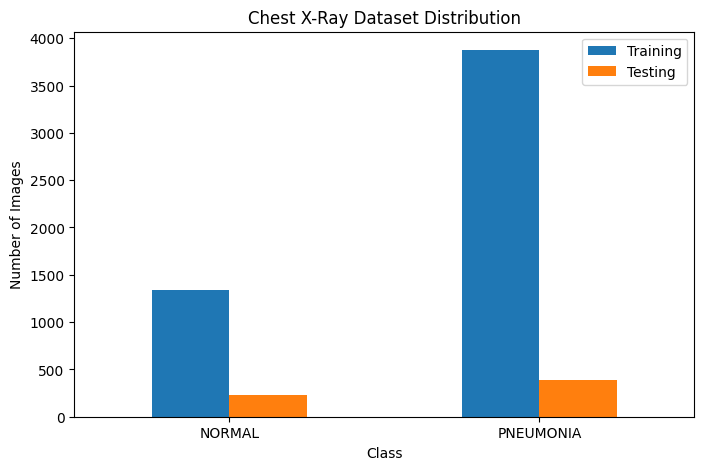

In [5]:
# CELL 5: Count images and inspect class distribution

def get_class_counts(folder):
    counts = {}

    for class_name in CLASS_NAMES:
        class_folder = os.path.join(folder, class_name)

        counts[class_name] = len([
            name for name in os.listdir(class_folder)
            if os.path.isfile(os.path.join(class_folder, name))
        ])

    return counts


train_counts = get_class_counts(TRAIN_DIR)
test_counts = get_class_counts(TEST_DIR)

print("Training images:", train_counts)
print("Testing images:", test_counts)

distribution = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Training": [train_counts[c] for c in CLASS_NAMES],
    "Testing": [test_counts[c] for c in CLASS_NAMES]
})

display(distribution)

distribution.plot(
    x="Class",
    y=["Training", "Testing"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Chest X-Ray Dataset Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

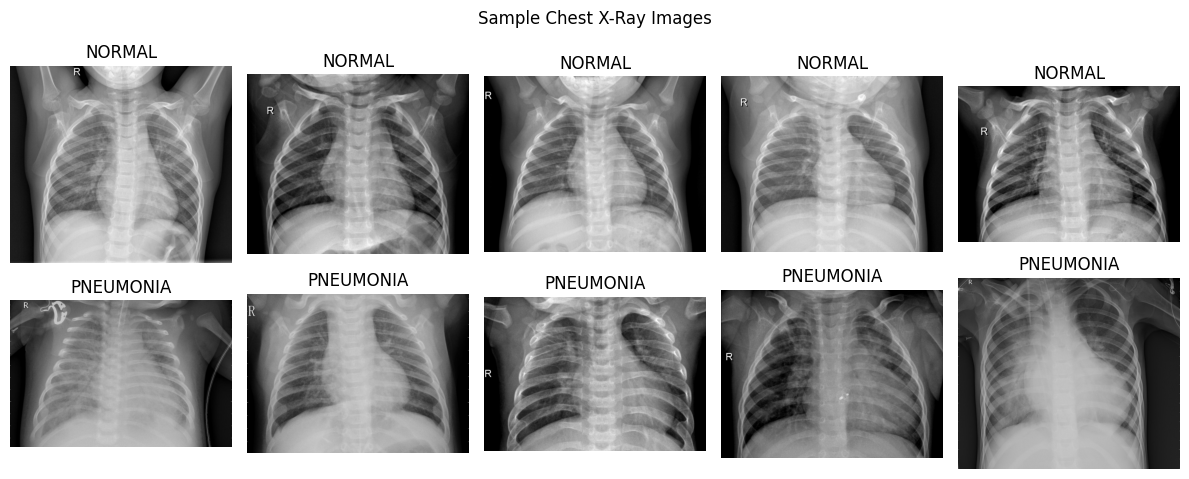

In [6]:
# CELL 6: Display sample X-ray images

def choose_images(folder, class_name, number=5):
    class_folder = os.path.join(folder, class_name)

    names = sorted([
        n for n in os.listdir(class_folder)
        if os.path.isfile(os.path.join(class_folder, n))
    ])

    return [
        os.path.join(class_folder, n)
        for n in names[:number]
    ]


normal_samples = choose_images(TRAIN_DIR, "NORMAL", 5)
pneumonia_samples = choose_images(TRAIN_DIR, "PNEUMONIA", 5)

plt.figure(figsize=(12, 5))

for index, path in enumerate(normal_samples):
    image = Image.open(path)
    plt.subplot(2, 5, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

for index, path in enumerate(pneumonia_samples):
    image = Image.open(path)
    plt.subplot(2, 5, index + 6)
    plt.imshow(image, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.suptitle("Sample Chest X-Ray Images")
plt.tight_layout()
plt.show()

In [7]:
# CELL 7: Create training and validation datasets

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_RATIO = 0.15

# The original validation folder contains very few images.
# Therefore, this project creates a fresh validation split from training data.

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_RATIO,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_RATIO,
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_ds.class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 5216 files belonging to 2 classes.
Using 4434 files for training.
Found 5216 files belonging to 2 classes.
Using 782 files for validation.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']


In [8]:
# CELL 8: Calculate class weights

# Read labels from the training dataset to compensate for class imbalance.

training_labels = []

for _, labels in train_ds:
    training_labels.extend(
        labels.numpy().reshape(-1).astype(int)
    )

training_labels = np.array(training_labels)

class_total = np.bincount(training_labels)

total_samples = len(training_labels)
number_of_classes = len(CLASS_NAMES)

class_weights = {}

for class_id in range(number_of_classes):
    class_weights[class_id] = (
        total_samples /
        (number_of_classes * class_total[class_id])
    )

print("Training class counts:", class_total)
print("Class weights:", class_weights)

Training class counts: [1151 3283]
Class weights: {0: np.float64(1.9261511728931364), 1: np.float64(0.675296984465428)}


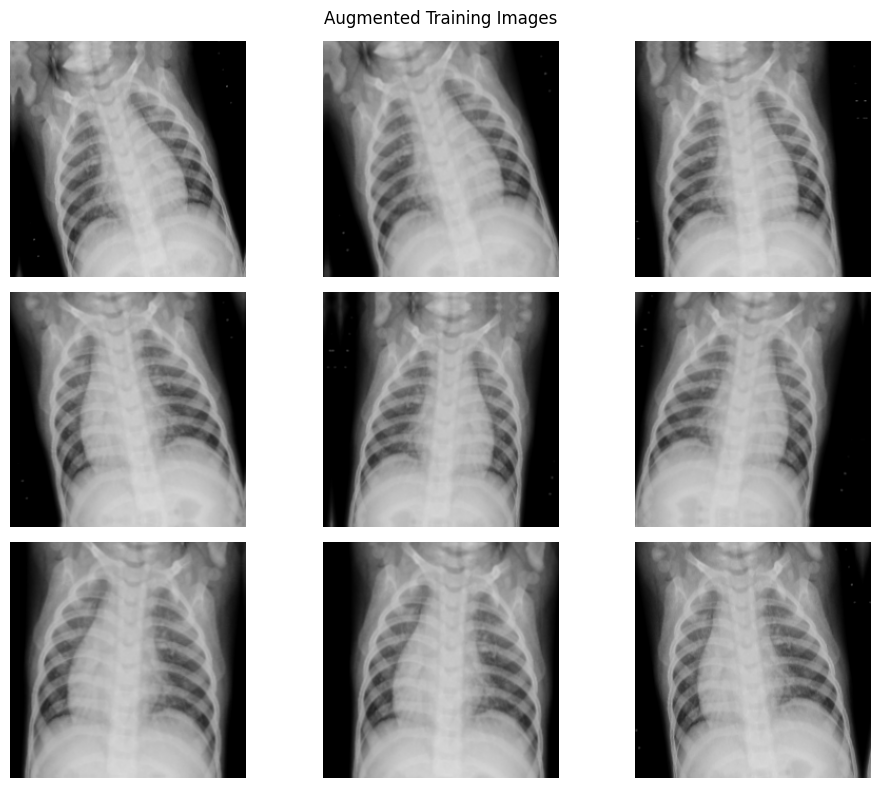

In [9]:
# CELL 9: Data augmentation pipeline

augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.04),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(
            height_factor=0.04,
            width_factor=0.04
        ),
        layers.RandomContrast(0.08)
    ],
    name="xray_augmentation"
)

# Visualize augmented versions of one image

for images, labels in train_ds.take(1):
    reference = images[0]
    break

plt.figure(figsize=(10, 8))

for i in range(9):
    transformed = augmentation(
        tf.expand_dims(reference, axis=0),
        training=True
    )[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(
        tf.clip_by_value(transformed, 0, 255).numpy().astype("uint8"),
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle("Augmented Training Images")
plt.tight_layout()
plt.show()

In [10]:
# CELL 10: Build a custom Residual CNN

def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x


cnn_input = keras.Input(
    shape=(*IMG_SIZE, 3),
    name="xray_input"
)

x = augmentation(cnn_input)
x = layers.Rescaling(1.0 / 255.0)(x)

x = layers.Conv2D(
    32,
    5,
    strides=2,
    padding="same",
    use_bias=False
)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

x = residual_block(x, 32)
x = residual_block(x, 64, stride=2)
x = residual_block(x, 64)

x = residual_block(x, 128, stride=2)
x = residual_block(x, 128)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4)
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.45)(x)

cnn_output = layers.Dense(
    1,
    activation="sigmoid",
    name="pneumonia_probability"
)(x)

custom_cnn = keras.Model(
    cnn_input,
    cnn_output,
    name="Residual_XRay_CNN"
)

custom_cnn.summary()

Model: "Residual_XRay_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xray_input          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_augmentation   │ (None, 224, 224,  │          0 │ xray_input[0][0]  │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ xray_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      9,216 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      9,216 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │     18,432 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 697,569 (2.66 MB)

 Trainable params: 695,201 (2.65 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [11]:
# CELL 11: Compile and train the custom CNN

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

cnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        "best_residual_cnn.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

cnn_history = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=18,
    class_weight=class_weights,
    callbacks=cnn_callbacks
)

Epoch 1/18
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 241ms/step - accuracy: 0.8678 - loss: 0.2994 - precision: 0.9750 - recall: 0.8431 - val_accuracy: 1.0000 - val_loss: 0.0268 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/18
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 224ms/step - accuracy: 0.9265 - loss: 0.2073 - precision: 0.9808 - recall: 0.9187 - val_accuracy: 0.9923 - val_loss: 0.0388 - val_precision: 1.0000 - val_recall: 0.9923 - learning_rate: 3.0000e-04
Epoch 3/18
139/139 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.9407 - loss: 0.1763 - precision: 0.9797 - recall: 0.9394 - val_accuracy: 0.9987 - val_loss: 0.0233 - val_precision: 1.0000 - val_recall: 0.9987 - learning_rate: 3.0000e-04
Epoch 4/18
139/139 ━━━━━━━━━━━━━━━━━━━━ 31s 223ms/step - accuracy: 0.9461 - loss: 0.1526 - precision: 0.9826 - recall: 0.9440 - val_accuracy: 0.0959 - val_loss: 5.8969 - val_precision: 1.0000 - val_recall: 0.0959 - learning_rate: 3.0000e-04
Epoch 5/18
139/139 ━━━━━━━━━━━━━━━━━

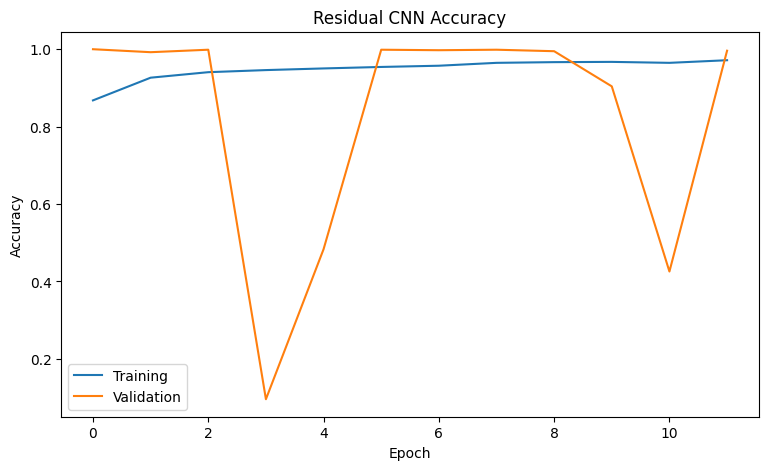

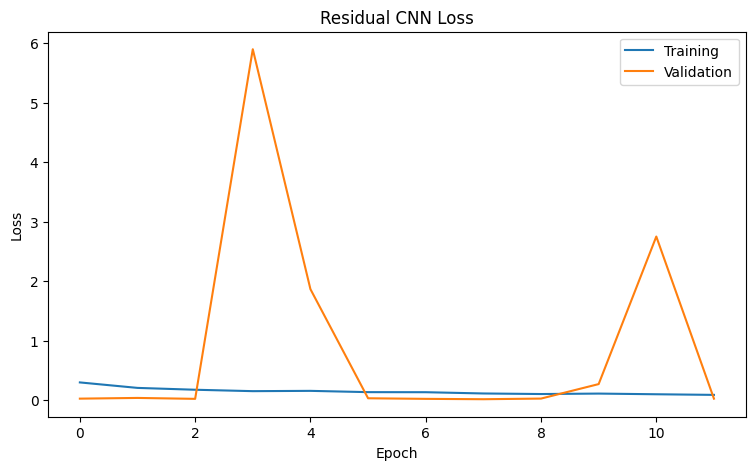

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.6506 - loss: 1.4457 - precision: 0.6419 - recall: 0.9974
Residual CNN test results:
loss: 1.4457
compile_metrics: 0.6506


In [12]:
# CELL 12: Plot custom CNN learning curves

history_df = pd.DataFrame(cnn_history.history)

plt.figure(figsize=(9, 5))
plt.plot(history_df["accuracy"], label="Training")
plt.plot(history_df["val_accuracy"], label="Validation")
plt.title("Residual CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["loss"], label="Training")
plt.plot(history_df["val_loss"], label="Validation")
plt.title("Residual CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

cnn_test_metrics = custom_cnn.evaluate(test_ds, verbose=1)

print("Residual CNN test results:")
for name, value in zip(custom_cnn.metrics_names, cnn_test_metrics):
    print(f"{name}: {value:.4f}")

In [13]:
# CELL 13: Build ResNet50V2 transfer-learning model

from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

resnet_base = ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)

resnet_base.trainable = False

resnet_input = keras.Input(
    shape=(*IMG_SIZE, 3),
    name="resnet_xray_input"
)

x = augmentation(resnet_input)
x = preprocess_input(x)

x = resnet_base(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(name="global_features")(x)

x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

resnet_output = layers.Dense(
    1,
    activation="sigmoid",
    name="pneumonia_probability"
)(x)

resnet_model = keras.Model(
    resnet_input,
    resnet_output,
    name="ResNet50V2_Pneumonia"
)

resnet_model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50V2_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet_xray_input (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xray_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_features                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_probability (Dense)   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,090,625 (91.90 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

In [14]:
# CELL 14: Train ResNet50V2 feature extractor

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

resnet_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.25,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        "best_resnet50v2_head.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,
    callbacks=resnet_callbacks
)

Epoch 1/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 46s 274ms/step - accuracy: 0.8045 - loss: 0.4220 - precision: 0.9650 - recall: 0.7636 - val_accuracy: 0.9066 - val_loss: 0.3236 - val_precision: 1.0000 - val_recall: 0.9066 - learning_rate: 1.0000e-04
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 239ms/step - accuracy: 0.8798 - loss: 0.2809 - precision: 0.9890 - recall: 0.8471 - val_accuracy: 0.9130 - val_loss: 0.3115 - val_precision: 1.0000 - val_recall: 0.9130 - learning_rate: 1.0000e-04
Epoch 3/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 319ms/step - accuracy: 0.9066 - loss: 0.2386 - precision: 0.9858 - recall: 0.8867 - val_accuracy: 0.9054 - val_loss: 0.3380 - val_precision: 1.0000 - val_recall: 0.9054 - learning_rate: 1.0000e-04
Epoch 4/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 43s 306ms/step - accuracy: 0.9168 - loss: 0.2138 - precision: 0.9853 - recall: 0.9010 - val_accuracy: 0.9348 - val_loss: 0.2579 - val_precision: 1.0000 - val_recall: 0.9348 - learning_rate: 1.0000e-04
Epoch 5/12
139/139 ━━━━━━━━━━━━━━━━━

In [15]:
# CELL 15: Fine-tune the upper ResNet50V2 layers

resnet_base.trainable = True

# Freeze most of the backbone and fine-tune only its upper layers.
fine_tune_start = len(resnet_base.layers) - 40

for layer in resnet_base.layers[:fine_tune_start]:
    layer.trainable = False

# Keep Batch Normalization layers frozen for more stable fine-tuning.
for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(
    layer.trainable
    for layer in resnet_base.layers
)

print("Trainable ResNet50V2 layers:", trainable_count)

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.25,
        patience=1,
        min_lr=1e-8
    ),
    keras.callbacks.ModelCheckpoint(
        "best_resnet50v2_finetuned.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

fine_tune_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)

Trainable ResNet50V2 layers: 30
Epoch 1/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 49s 278ms/step - accuracy: 0.9544 - loss: 0.1562 - precision: 0.9880 - recall: 0.9500 - val_accuracy: 0.9488 - val_loss: 0.2392 - val_precision: 1.0000 - val_recall: 0.9488 - learning_rate: 1.0000e-05
Epoch 2/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 240ms/step - accuracy: 0.9635 - loss: 0.1330 - precision: 0.9896 - recall: 0.9607 - val_accuracy: 0.9271 - val_loss: 0.3056 - val_precision: 1.0000 - val_recall: 0.9271 - learning_rate: 1.0000e-05
Epoch 3/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.9680 - loss: 0.1149 - precision: 0.9934 - recall: 0.9631 - val_accuracy: 0.9488 - val_loss: 0.2340 - val_precision: 1.0000 - val_recall: 0.9488 - learning_rate: 2.5000e-06
Epoch 4/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 243ms/step - accuracy: 0.9714 - loss: 0.1195 - precision: 0.9913 - recall: 0.9698 - val_accuracy: 0.9604 - val_loss: 0.2032 - val_precision: 1.0000 - val_recall: 0.9604 - learning_rate: 2.5000e-06
Epoch 5/

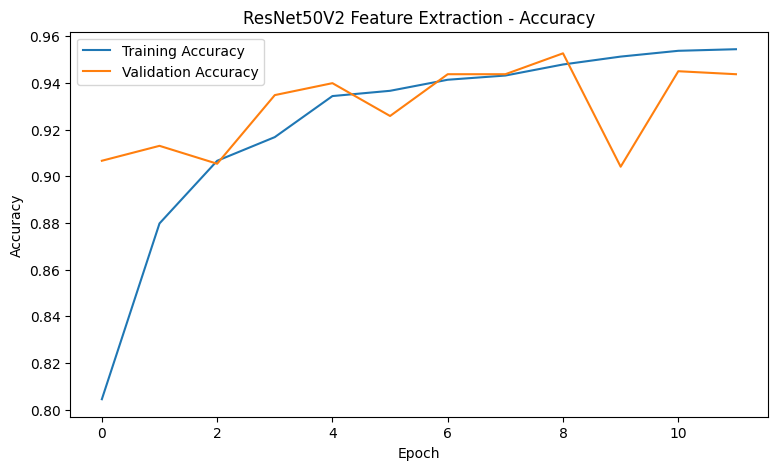

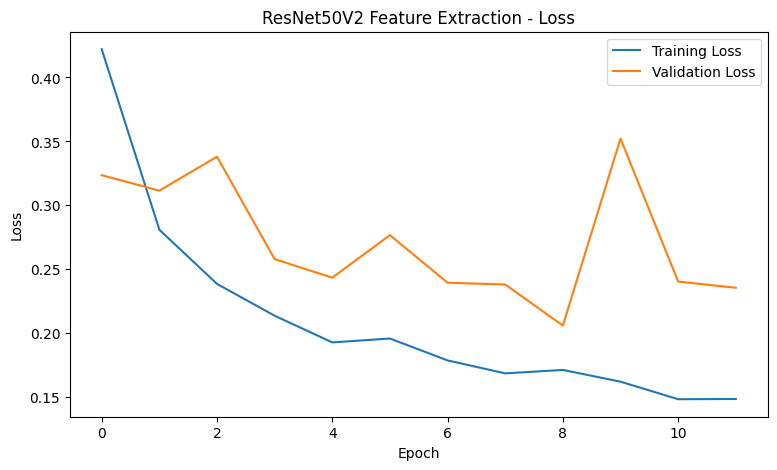

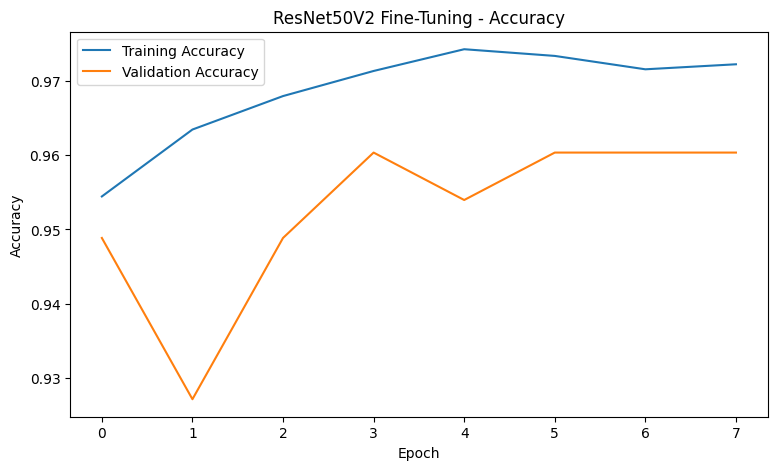

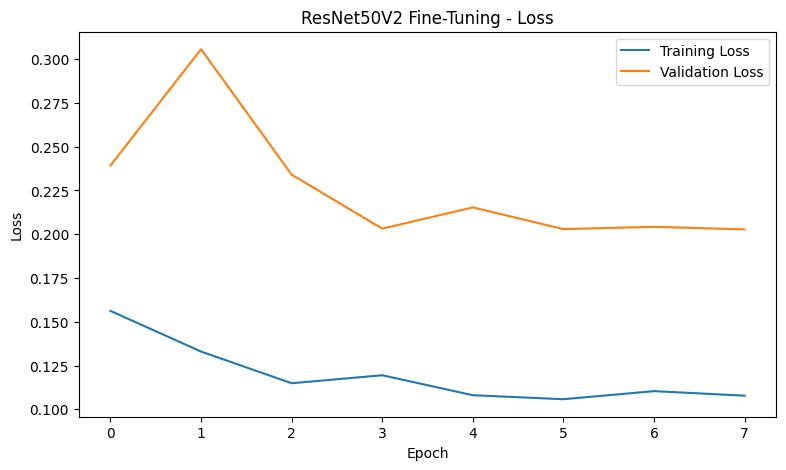

In [16]:
# CELL 16: Combine and display ResNet training curves

def plot_history(history, title):
    history_data = pd.DataFrame(history.history)

    plt.figure(figsize=(9, 5))
    plt.plot(
        history_data["accuracy"],
        label="Training Accuracy"
    )
    plt.plot(
        history_data["val_accuracy"],
        label="Validation Accuracy"
    )
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(
        history_data["loss"],
        label="Training Loss"
    )
    plt.plot(
        history_data["val_loss"],
        label="Validation Loss"
    )
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


plot_history(
    resnet_history,
    "ResNet50V2 Feature Extraction"
)

plot_history(
    fine_tune_history,
    "ResNet50V2 Fine-Tuning"
)

In [17]:
# CELL 17: Create a reusable prediction function

def collect_predictions(model, dataset):
    probabilities = model.predict(
        dataset,
        verbose=0
    ).reshape(-1)

    actual = np.concatenate([
        labels.numpy().reshape(-1)
        for _, labels in dataset
    ]).astype(int)

    return actual, probabilities


val_true, val_probability = collect_predictions(
    resnet_model,
    val_ds
)

test_true, test_probability = collect_predictions(
    resnet_model,
    test_ds
)

print("Validation samples:", len(val_true))
print("Test samples:", len(test_true))

Validation samples: 782
Test samples: 624


In [18]:
# CELL 18: Select a decision threshold using validation data

def select_threshold(y_true, probabilities):
    candidates = np.arange(0.20, 0.81, 0.01)

    best_threshold = 0.50
    best_f1 = -1

    for threshold in candidates:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        score = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    return best_threshold, best_f1


OPTIMAL_THRESHOLD, validation_f1 = select_threshold(
    val_true,
    val_probability
)

print(
    f"Selected threshold: {OPTIMAL_THRESHOLD:.2f}"
)

print(
    f"Validation F1 at selected threshold: {validation_f1:.4f}"
)

print(
    "Important: the test set was not used to choose this threshold."
)

Selected threshold: 0.20
Validation F1 at selected threshold: 0.9897
Important: the test set was not used to choose this threshold.


FINAL RESNET50V2 RESULTS
----------------------------------------
Accuracy    : 0.8702
Precision   : 0.8337
Recall      : 0.9897
Specificity : 0.6709
F1 Score    : 0.9050
ROC-AUC     : 0.9580

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.98      0.67      0.79       234
   PNEUMONIA       0.83      0.99      0.91       390

    accuracy                           0.87       624
   macro avg       0.90      0.83      0.85       624
weighted avg       0.89      0.87      0.86       624



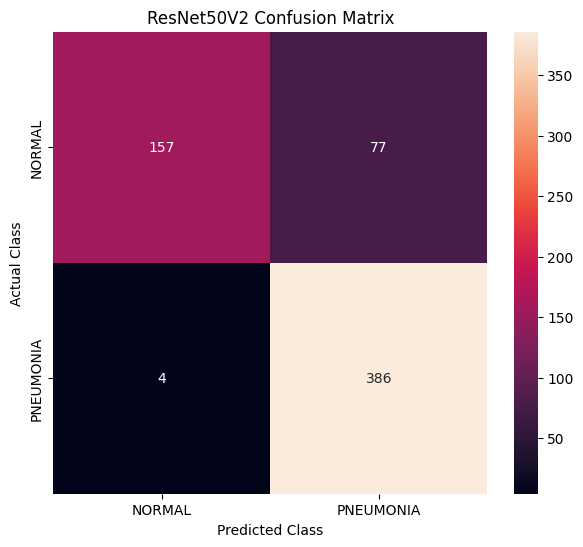

In [19]:
# CELL 19: Detailed final model evaluation

test_prediction = (
    test_probability >= OPTIMAL_THRESHOLD
).astype(int)

accuracy = accuracy_score(test_true, test_prediction)
precision = precision_score(
    test_true,
    test_prediction,
    zero_division=0
)
recall = recall_score(
    test_true,
    test_prediction,
    zero_division=0
)
f1 = f1_score(
    test_true,
    test_prediction,
    zero_division=0
)
roc_auc = roc_auc_score(
    test_true,
    test_probability
)

cm = confusion_matrix(
    test_true,
    test_prediction
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp) if (tn + fp) else 0

print("FINAL RESNET50V2 RESULTS")
print("-" * 40)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

print("\nClassification Report")
print(
    classification_report(
        test_true,
        test_prediction,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("ResNet50V2 Confusion Matrix")
plt.show()

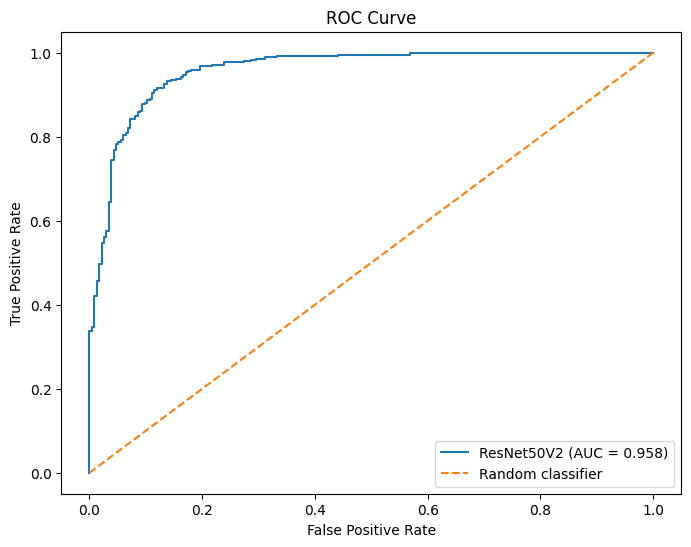

In [20]:
# CELL 20: ROC curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    test_true,
    test_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ResNet50V2 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

,Model,Accuracy,F1 Score,ROC-AUC
0,Residual CNN,0.650641,0.781124,0.895075
1,ResNet50V2 Fine-Tuned,0.870192,0.905041,0.958021


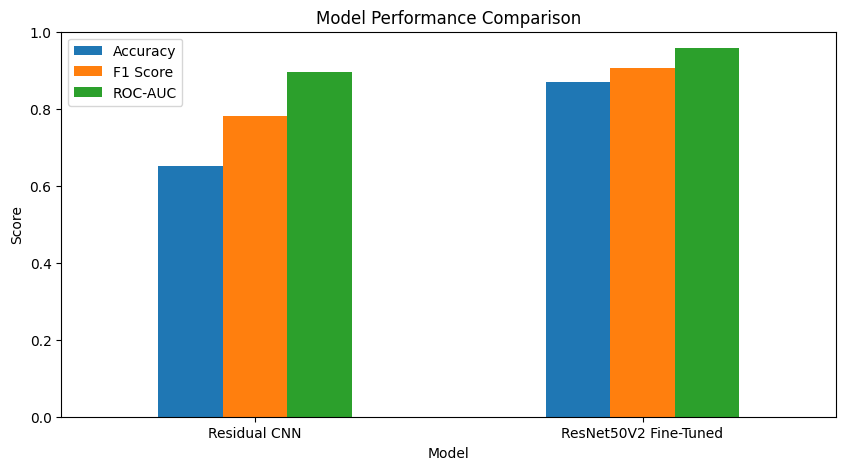

In [21]:
# CELL 21: Compare the two models

cnn_true, cnn_probability = collect_predictions(
    custom_cnn,
    test_ds
)

cnn_prediction = (
    cnn_probability >= 0.50
).astype(int)

cnn_accuracy = accuracy_score(
    cnn_true,
    cnn_prediction
)

cnn_f1 = f1_score(
    cnn_true,
    cnn_prediction,
    zero_division=0
)

comparison = pd.DataFrame({
    "Model": [
        "Residual CNN",
        "ResNet50V2 Fine-Tuned"
    ],
    "Accuracy": [
        cnn_accuracy,
        accuracy
    ],
    "F1 Score": [
        cnn_f1,
        f1
    ],
    "ROC-AUC": [
        roc_auc_score(cnn_true, cnn_probability),
        roc_auc
    ]
})

display(comparison)

comparison.plot(
    x="Model",
    y=["Accuracy", "F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(10, 5)
)

plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [22]:
# CELL 22: Grad-CAM implementation for ResNet50V2

# Find the last suitable convolutional layer automatically.
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer

        if isinstance(layer, keras.Model):
            for inner_layer in reversed(layer.layers):
                if isinstance(inner_layer, layers.Conv2D):
                    return inner_layer

    raise ValueError("No convolutional layer was found.")


last_conv_layer = find_last_conv_layer(resnet_base)

print("Grad-CAM layer:", last_conv_layer.name)

Grad-CAM layer: conv5_block3_3_conv


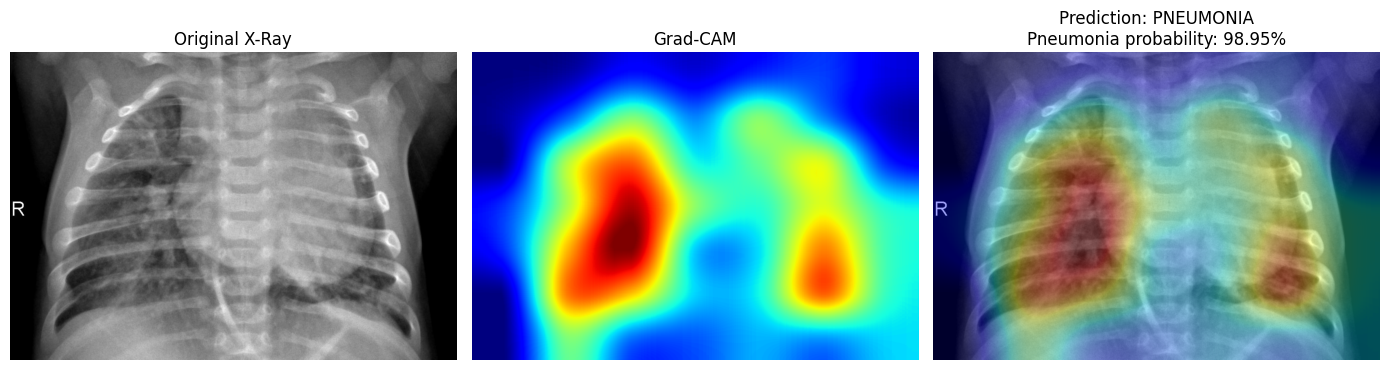

Predicted class: PNEUMONIA
Pneumonia probability: 98.95%
Reported confidence: 98.95%
Decision threshold: 0.20


('PNEUMONIA', 0.9894782900810242)

In [23]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# CELL 23: Generate and display Grad-CAM

def make_gradcam_heatmap(image_array, model, backbone):
    image_tensor = tf.cast(image_array, tf.float32)
    image_tensor = preprocess_input(image_tensor)

    with tf.GradientTape() as tape:
        feature_maps = backbone(
            image_tensor,
            training=False
        )

        tape.watch(feature_maps)

        pooled = model.get_layer(
            "global_features"
        )(feature_maps)

        dense_layer = None
        batch_norm_layer = None
        dropout_layer = None
        output_layer = None

        # FIX: Find the dense layer dynamically by its class type
        # to avoid string mismatch issues (e.g., 'dense' vs 'dense_1')
        for layer in model.layers:
            if isinstance(layer, layers.Dense) and layer.name != "pneumonia_probability":
                dense_layer = layer
            elif isinstance(layer, layers.BatchNormalization):
                batch_norm_layer = layer
            elif isinstance(layer, layers.Dropout):
                dropout_layer = layer
            elif layer.name == "pneumonia_probability":
                output_layer = layer

        # Check if the dense layer was successfully found
        if dense_layer is None:
            raise ValueError(
                "Could not find the intermediate dense layer in the model. "
                "Verify your model architecture and layer types."
            )

        x = dense_layer(pooled)

        if batch_norm_layer is not None:
            x = batch_norm_layer(x, training=False)

        if dropout_layer is not None:
            x = dropout_layer(x, training=False)

        prediction = output_layer(x)

    gradients = tape.gradient(
        prediction,
        feature_maps
    )

    weights = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    heatmap = tf.reduce_sum(
        feature_maps * weights[:, None, None, :],
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap[0]

    maximum = tf.reduce_max(heatmap)

    if maximum > 0:
        heatmap = heatmap / maximum

    return heatmap.numpy()


def explain_xray(image_path):
    original = Image.open(image_path).convert("RGB")
    resized = original.resize(IMG_SIZE)

    image_array = np.asarray(
        resized,
        dtype=np.float32
    )

    batch = np.expand_dims(
        image_array,
        axis=0
    )

    probability = float(
        resnet_model.predict(
            batch,
            verbose=0
        )[0][0]
    )

    predicted_class = (
        "PNEUMONIA"
        if probability >= OPTIMAL_THRESHOLD
        else "NORMAL"
    )

    confidence = (
        probability
        if predicted_class == "PNEUMONIA"
        else 1 - probability
    )

    heatmap = make_gradcam_heatmap(
        batch,
        resnet_model,
        resnet_base
    )

    heatmap_image = Image.fromarray(
        np.uint8(255 * heatmap)
    ).resize(original.size)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original X-Ray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_image, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(original, cmap="gray")
    plt.imshow(
        heatmap_image,
        cmap="jet",
        alpha=0.35
    )
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Pneumonia probability: {probability * 100:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Predicted class:", predicted_class)
    print(f"Pneumonia probability: {probability * 100:.2f}%")
    print(f"Reported confidence: {confidence * 100:.2f}%")
    print(f"Decision threshold: {OPTIMAL_THRESHOLD:.2f}")

    return predicted_class, probability


# Test Grad-CAM on one test image
example_path = test_ds.class_names if False else choose_images(TEST_DIR, "PNEUMONIA", 1)[0]
explain_xray(example_path)


Upload a chest X-ray image


Saving person88_bacteria_438.jpeg to person88_bacteria_438.jpeg
Selected file: person88_bacteria_438.jpeg


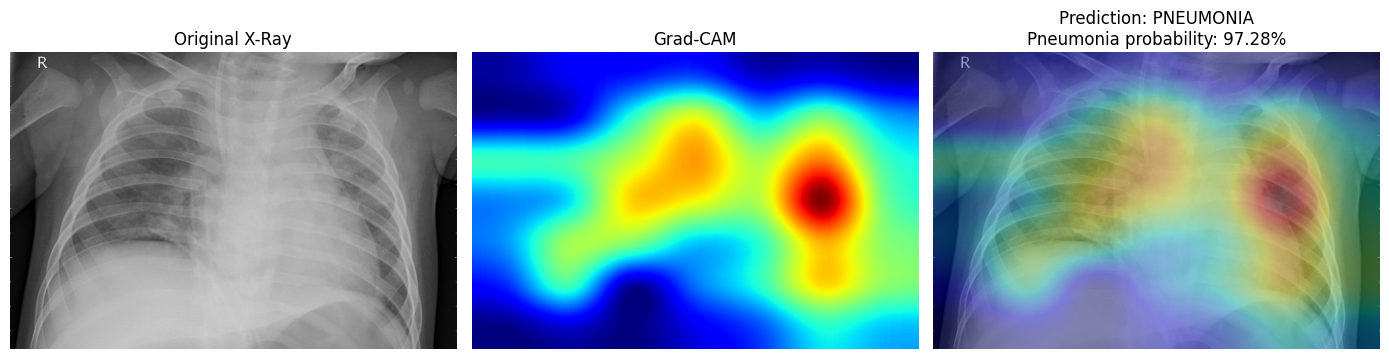

Predicted class: PNEUMONIA
Pneumonia probability: 97.28%
Reported confidence: 97.28%
Decision threshold: 0.20


In [26]:
# CELL 24: Upload and classify a new X-ray

from google.colab import files

print("Upload a chest X-ray image")
new_upload = files.upload()

new_image_path = next(iter(new_upload))

print("Selected file:", new_image_path)

prediction_class, prediction_probability = explain_xray(
    new_image_path
)

In [25]:
# CELL 25: Save the final model

FINAL_MODEL_PATH = "pneumonia_resnet50v2_final.keras"

resnet_model.save(FINAL_MODEL_PATH)

print("Final model saved as:", FINAL_MODEL_PATH)

# Reload the saved model to verify that it can be restored.
reloaded_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

print("Saved model loaded successfully.")

reloaded_metrics = reloaded_model.evaluate(
    test_ds,
    verbose=1
)

print("Reloaded model evaluation completed.")

Final model saved as: pneumonia_resnet50v2_final.keras
Saved model loaded successfully.
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.8990 - loss: 0.3096 - precision: 0.8811 - recall: 0.9692
Reloaded model evaluation completed.
